# **Digitalisasi Catatan Tulisan Tangan Mahasiswa Berbasis Web**

## **Section 1: Project Overview**

### **Latar Belakang**
Optical Character Recognition (OCR) adalah teknologi yang mengubah gambar teks menjadi teks yang dapat diedit secara digital. Dalam konteks mahasiswa, teknologi ini membantu mendigitalisasi catatan fisik agar mudah dicari dan disimpan.

### **Problem Statement**
Tulisan tangan memiliki variasi gaya yang sangat tinggi, sehingga OCR tradisional seringkali gagal mengenali karakter dengan akurasi tinggi.

### **Objective**
Membangun model OCR yang akurat menggunakan arsitektur **TrOCR** (Transformer-based OCR) untuk mengenali teks dari dokumen.

### **Arsitektur TrOCR**
TrOCR menggabungkan **Vision Transformer (ViT)** sebagai encoder dan **Transformer Decoder** untuk pemrosesan bahasa.

**Diagram Alir:**
`Image` -> `ViT Encoder` -> `Transformer Decoder` -> `Predicted Text`

In [2]:
!pip install -q transformers datasets evaluate jiwer torch torchvision opencv-python

### **Setup Kaggle API**
Silakan unggah file `kaggle.json` Anda (didapat dari Kaggle Account -> Create New API Token) untuk mengunduh dataset secara otomatis.

In [24]:
from google.colab import files
import os

# Upload kaggle.json
if not os.path.exists('/root/.kaggle/kaggle.json'):
    uploaded = files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✓ Kaggle API Key berhasil dikonfigurasi.")

Saving kaggle.json to kaggle.json
✓ Kaggle API Key berhasil dikonfigurasi.


### **Download Dataset dari Kaggle**

In [34]:
# Unduh dataset dari Kaggle (olafkrastovski/handwritten-digits-0-9)
# Hanya mendownload file zip tanpa ekstraksi otomatis
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

import os

if os.path.exists('handwritten-digits-0-9.zip'):
    print("✓ Dataset ZIP berhasil diunduh.")
else:
    print("❌ Download gagal. Pastikan API Key sudah benar dan Rules di Kaggle sudah di-accept.")

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)
✓ Dataset ZIP berhasil diunduh.


## **Section 2: Import Libraries**

In [35]:
import os
import json
import zipfile
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator
)
from evaluate import load

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## **Section 3: Data Loading & Parsing**
Kita akan mengekstrak file zip dan membuat parser untuk membaca pasangan Gambar-JSON.

In [38]:
import os
import zipfile
import pandas as pd

zip_path = '/content/handwritten-digits-0-9.zip'
extract_path = '/content/dataset_kaggle_digit'

# Ekstraksi dataset baru jika belum ada
if not os.path.exists(extract_path):
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✓ Dataset digit berhasil diekstrak.")
    else:
        print("☁ File Zip tidak ditemukan!")

def parse_digit_dataset(root_dir):
    data = []
    # Iterasi melalui subfolder (0, 1, 2, ..., 9)
    for label in os.listdir(root_dir):
        label_path = os.path.join(root_dir, label)

        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(label_path, file)
                    # Gunakan nama folder sebagai teks/label target
                    data.append({'image_path': img_path, 'text': str(label)})

    return pd.DataFrame(data)

# Menjalankan parser pada folder hasil ekstrak
# Catatan: Kaggle sering mengekstrak ke subfolder lagi, sesuaikan jika perlu
df = parse_digit_dataset(extract_path)

if df.empty:
    print("☁ DataFrame kosong. Memeriksa sub-direktori...")
    # Coba cek satu level lebih dalam jika ada folder pembungkus di dalam zip
    subfolders = [f.path for f in os.scandir(extract_path) if f.is_dir()]
    if subfolders:
        df = parse_digit_dataset(subfolders[0])

if not df.empty:
    print(f"✓ Berhasil memuat {len(df)} data digit.")
    display(df.sample(5) if len(df) > 5 else df.head())
else:
    print("❌ Gagal memuat data. Pastikan path ekstrak benar.")

✓ Berhasil memuat 21555 data digit.


,image_path,text
8645,/content/dataset_kaggle_digit/5/Five_full (943...,5
12353,/content/dataset_kaggle_digit/4/Four_full (787...,4
3261,/content/dataset_kaggle_digit/0/Zero_full (147...,0
11187,/content/dataset_kaggle_digit/4/Four_full (726...,4
19142,/content/dataset_kaggle_digit/6/Six_full (1071...,6


## **Section 4: Exploratory Data Analysis (EDA)**
Visualisasi statistik teks dan contoh data.

Total data: 21555
Rata-rata panjang teks: 1.00 karakter


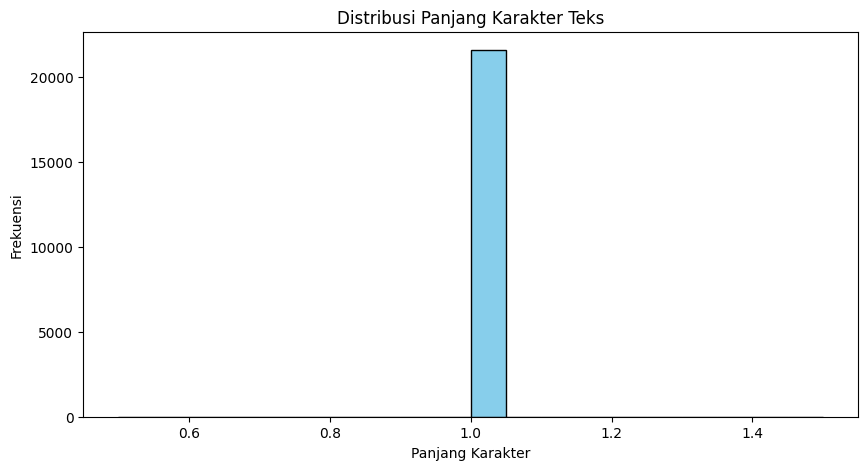

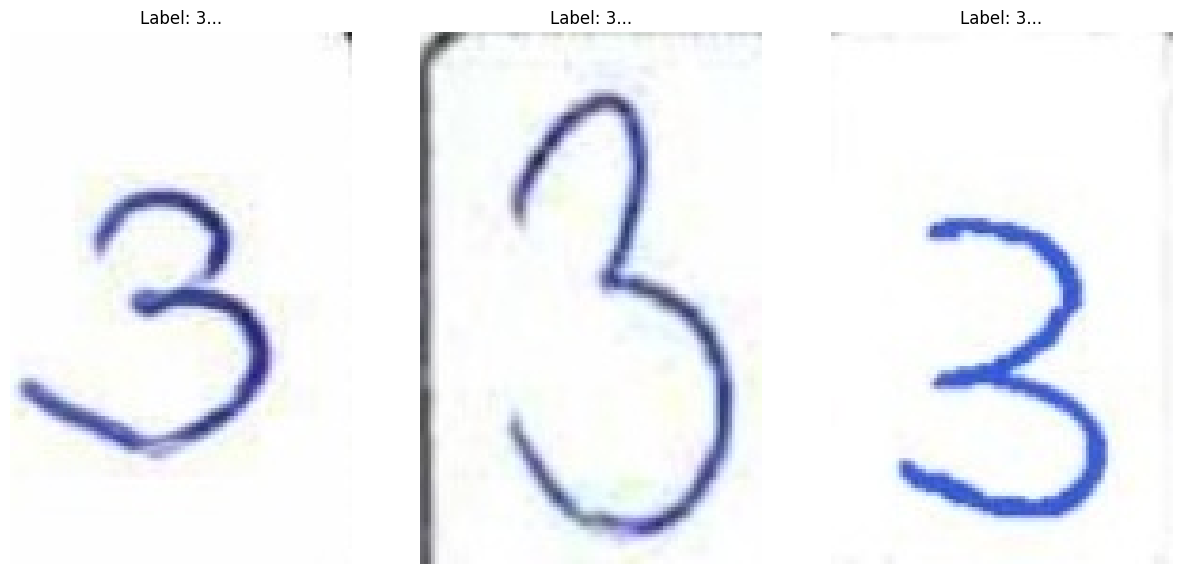

In [39]:
if not df.empty:
    # Hitung statistik dasar
    df['text_len'] = df['text'].apply(len)

    print(f"Total data: {len(df)}")
    print(f"Rata-rata panjang teks: {df['text_len'].mean():.2f} karakter")

    # Visualisasi Distribusi Panjang Teks
    plt.figure(figsize=(10, 5))
    plt.hist(df['text_len'], bins=20, color='skyblue', edgecolor='black')
    plt.title('Distribusi Panjang Karakter Teks')
    plt.xlabel('Panjang Karakter')
    plt.ylabel('Frekuensi')
    plt.show()

    # Visualisasi Contoh Gambar
    plt.figure(figsize=(15, 8))
    for i in range(min(3, len(df))):
        img = Image.open(df.iloc[i]['image_path'])
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(f"Label: {df.iloc[i]['text'][:30]}...")
        plt.axis('off')
    plt.show()
else:
    print("⚠ DataFrame masih kosong. Pastikan cell Section 3 dijalankan ulang.")

## **Section 5: Preprocessing**
Menggunakan `TrOCRProcessor` untuk normalisasi gambar dan tokenisasi teks.

In [40]:
from transformers import TrOCRProcessor

try:
    # Menggunakan model printed karena dataset terlihat seperti dokumen/bill
    processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
    print("✓ Processor loaded successfully.")
except Exception as e:
    print(f"⚠ Error loading processor: {e}")

✓ Processor loaded successfully.


## **Section 6: Train-Validation-Test Split**
Membagi data dengan rasio 80:10:10.

In [41]:
if not df.empty:
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)

    train_df.reset_index(drop=True, inplace=True)
    val_df.reset_index(drop=True, inplace=True)
    test_df.reset_index(drop=True, inplace=True)

    print(f"✓ Training set: {len(train_df)}")
    print(f"✓ Validation set: {len(val_df)}")
    print(f"✓ Test set: {len(test_df)}")
else:
    print("⚠ Tidak bisa melakukan split karena DataFrame kosong.")

✓ Training set: 17244
✓ Validation set: 2155
✓ Test set: 2156


## **Section 7: Dataset Class**
Implementasi PyTorch Dataset untuk TrOCR.

In [42]:
class OCRDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file_name = self.df['image_path'][idx]
        image = Image.open(file_name).convert("RGB")

        # Preprocess image
        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        # Preprocess text
        text = self.df['text'][idx]
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True
        ).input_ids

        # Important: map pad_token_id to -100 so it is ignored by the loss function
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        encoding = {"pixel_values": pixel_values.squeeze(), "labels": torch.tensor(labels)}
        return encoding

## **Section 8: Load Pretrained TrOCR Model**
Memuat arsitektur `VisionEncoderDecoderModel` dari Microsoft.

In [43]:
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")

# Set model configuration
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

# Beam search parameters
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

model.to(device)

print(f"Model parameters: {model.num_parameters():,}")

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 333,921,792


## **Section 9: Fine-Tuning with Seq2SeqTrainer**
Konfigurasi training dengan EarlyStopping dan ModelCheckpoint.

In [48]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback, default_data_collator
from evaluate import load

# 1. Definisikan Metrics (harus sebelum Trainer)
cer_metric = load("cer")
wer_metric = load("wer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    # Decode predictions and labels
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer, "wer": wer}

# 2. Dataset setup
train_dataset = OCRDataset(train_df, processor)
eval_dataset = OCRDataset(val_df, processor)

# Fix: Move generation parameters from model.config to model.generation_config
generation_params = ['max_length', 'early_stopping', 'num_beams', 'length_penalty', 'no_repeat_ngram_size']
for param in generation_params:
    if hasattr(model.config, param):
        setattr(model.generation_config, param, getattr(model.config, param))
        delattr(model.config, param)

data_collator = default_data_collator

# 3. Konfigurasi Training
training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    eval_strategy="steps",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    fp16=torch.cuda.is_available(),
    output_dir="./checkpoint_trocr",
    logging_steps=10,
    save_steps=100,
    eval_steps=100,
    num_train_epochs=1,
    learning_rate=5e-5,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    remove_unused_columns=False,
)

# 4. Inisialisasi Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✓ Trainer diperbarui dengan metrics. Silakan jalankan trainer.train()")

✓ Trainer diperbarui dengan metrics. Silakan jalankan trainer.train()


In [ ]:
print("Starting training...")
trainer.train()
print("Training complete!")

Starting training...


Step,Training Loss,Validation Loss


## **Section 10: Training Visualization**

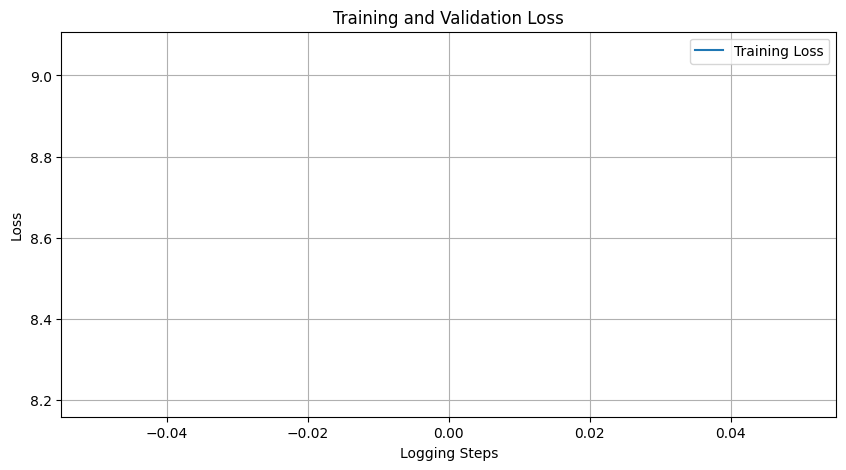

In [21]:
def plot_history():
    if hasattr(trainer, 'state') and trainer.state.log_history:
        history = trainer.state.log_history
        train_loss = [x['loss'] for x in history if 'loss' in x]
        val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

        plt.figure(figsize=(10, 5))
        if train_loss:
            plt.plot(train_loss, label='Training Loss')
        if val_loss:
            plt.plot(val_loss, label='Validation Loss')

        plt.title('Training and Validation Loss')
        plt.xlabel('Logging Steps')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("☁ History belum tersedia. Anda harus menjalankan trainer.train() di Section 9 sampai selesai terlebih dahulu.")

plot_history()

## **Section 11: Evaluation (CER & WER)**
Menghitung Character Error Rate (CER) dan Word Error Rate (WER) menggunakan library `jiwer`.

In [23]:
cer_metric = load("cer")
wer_metric = load("wer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    # Decode predictions and labels
    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)

    return {"cer": cer, "wer": wer}

# Pastikan trainer menggunakan compute_metrics yang baru didefinisikan
trainer.compute_metrics = compute_metrics

# Evaluasi model pada test set
print("Sedang mengevaluasi...")
results = trainer.evaluate(eval_dataset=OCRDataset(test_df, processor))

# Tampilkan hasil
if 'eval_cer' in results:
    print(f"Test CER: {results['eval_cer']:.4f}")
    print(f"Test WER: {results['eval_wer']:.4f}")
else:
    print("Metrics tidak ditemukan. Pastikan 'predict_with_generate' aktif di training_args.")

Sedang mengevaluasi...


KeyboardInterrupt: 

## **Section 12: Baseline Comparison with EasyOCR**

In [ ]:
!pip install -q easyocr
import easyocr

reader = easyocr.Reader(['en'])

def evaluate_easyocr(test_df):
    preds = []
    refs = []
    for _, row in test_df.head(10).iterrows():
        result = reader.readtext(row['image_path'], detail=0)
        preds.append(" ".join(result))
        refs.append(row['text'])

    cer = cer_metric.compute(predictions=preds, references=refs)
    print(f"EasyOCR Baseline - CER: {cer:.4f}")
    return cer

cer_baseline = evaluate_easyocr(test_df)

## **Section 13: Error Analysis**

In [ ]:
def error_analysis(test_df, model, processor):
    model.eval()
    results = []
    for _, row in test_df.head(10).iterrows():
        image = Image.open(row['image_path']).convert("RGB")
        pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

        with torch.no_grad():
            generated_ids = model.generate(pixel_values)
        generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        cer = cer_metric.compute(predictions=[generated_text], references=[row['text']])
        results.append({
            'Ground Truth': row['text'],
            'Prediction': generated_text,
            'CER': cer
        })

    analysis_df = pd.DataFrame(results).sort_values(by='CER')
    print("Analisis Prediksi Model (Terbaik ke Terburuk):")
    display(analysis_df)

## **Section 14: Inference Demo**

In [ ]:
def predict_text(image_path):
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    model.eval()
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    plt.figure(figsize=(8, 4))
    plt.imshow(image)
    plt.title(f"Predicted Text: {generated_text}")
    plt.axis('off')
    plt.show()
    return generated_text

# predict_text(test_df.iloc[0]['image_path'])